This Notebook is to centralize answering common questions players have for me, and things that I should know.


In [1]:
from os import path 

from src.graphing_tools import *

import src.db_operations as db_operations
import src.helpers as helpers

import pandas as pd
import matplotlib.pyplot as plt

# full_df = pd.DataFrame(db_operations.get_table('main_table', 'all_events'))
full_df = pd.read_json(path.join('.json','ROADTRIP.json'))

full_df['date'] = pd.to_datetime(full_df.date)

top_df = full_df[full_df['wins'] > 5]

results = full_df.groupby('boss').describe().loc[:,'wins'].loc[:, ['count', 'mean']]

results.sort_values('mean', inplace=True)
results=results[results['mean'] > 3]

In [2]:

sleepers = results[results['count'] < 10]
performers = results[results['count'] >4]

# sleepers.tail(10)

In [3]:
# Who are the top 10 performers overall?
top_10_df = performers.tail(10)
top_10_df

top_10_df.reset_index(inplace=True)

big_10_names = top_10_df.iloc[:].boss.values
big_10_names = list(big_10_names)
big_10_names

['Fated One of Ever-changing, Krysrain Cadenza',
 "Youthberk 'Skyfall Arms: Rebuild'",
 'Oblivionis the Noble',
 'Galactic B-Hero, Stately Crozard',
 'Sealed Blaze of Arbitration, Bavsargra Aksayya',
 'Future Force Possessor, Tasuku Ryuenji',
 'Rewrite the Star, Vyrgilla',
 'Aurora Battle Princess, Seraph Clearlight',
 'Sugary and Scary Land, Heartluru',
 'Deeplands, Reguregnus']

This is a bit rough, but what if we try averaging across formats?

In [4]:
formats = [
(
'2025-10-24',
'set 10'),
(
'2025-12-1',
'banlist'),
(
'2025-12-19',
'set 11'),
(
'2026-1-30',
'lyrical'),
(
'2026-2-27',
'set 12'),
]

In [5]:
# for df in [full_df, top_df]:
#     graph_over_format(
#         df, 
#         'boss', 
#         'wins', 
#         big_10_names, 
#         formats)

#     graph_over_format(
#         df, 
#         'stand_heals', 
#         'wins', 
#         [i for i in range(5)], 
#         formats)

#     graph_over_format(
#         df,
#         'boss',
#         'stand_heals',
#         big_10_names,
#         formats
#     )

In [6]:
# OTS = [
#     "Red",
#     "Blue",
#     "Purple",
#     "Yellow",
#     "Green",

#     # "Dragveda",
#     # "Eldobreath",
#     # "Blessfavor",
#     # "DS OT",
#     # "Keter OT",
#     # "Lyrical"
# ]
# for df in [full_df, top_df]:
#     graph_over_format(
#         df, 
#         'over_trigger', 
#         'wins', 
#         OTS, 
#         formats)

With this, we can combine it with the tool from earlier to graph how particular cards peform in decks. (Curtis' request)

In [7]:
# for df in [full_df, top_df]:
#     graph_card_peformance_for_boss(
#         'Avarice Wrester',
#         "Sugary and Scary Land, Heartluru",
#         df,
#         formats)

Marse wants to see a breakdown not just of win rates, but popularity over time.

We need to make a tool to determine the percentage each deck was in the tournament overall, and then graph that overtime, to see if perhaps representation bias could be at play. It could be wise to graph this data again on top performers (6 wins or more)

In [8]:
from collections import defaultdict as dd
def boss_representation_in_format(df:pd.DataFrame) -> dd:
    """ 
    
    """
    df_date = get_df_date(df)
    bosses_present = dd(int)
    total = 0
    for i, row in df.iterrows():
        bosses_present[row.boss] += 1
        total += 1

    boss_rep = {k: v / total for k, v in bosses_present.items()}
    boss_rep = helpers.sort_dict_by_values(boss_rep)

    df = pd.DataFrame({'boss': pd.Series(boss_rep.keys()),
                      'rep': pd.Series(boss_rep.values()),
                      'date': df_date
                     })
    return df

def get_df_date(df:pd.DataFrame):
    return df.reset_index().loc[0,'date']

In [17]:
champ_df = full_df[full_df['name']=='Champion']
champ_df.head()

,rank,name,boss,wins,nation,decklog,deck,location,region,date,regalis_piece,crit_heal_count,draw_count,stand_heal_count,stand_heals,crit_heals,sheild_draws,shield_fronts,soul_fronts,over_trigger
0,1,Champion,"Savior of the World, Kyoya Gaen",10,Buddyfight,1APFF,{'RideDeck': {'DZ-TB01/KR17EN : Savior of the ...,TX,NA,2025-11-22,Bracing Angel Ladder,0,1,0,0,0,0,0,0,Red
1,1,Champion,"Dragheart, Luard",11,Keter Sanctuary,1047Z,"{'RideDeck': {'D-SS10/001EN-R : Dragheart, Lua...","Melbourne, Australia",AO,2026-02-28,Protection: Twincast,0,1,1,1,0,0,3,3,Purple
2,1,Champion,"Deeplands, Reguregnus",11,Stoicheia,5F2LR,"{'RideDeck': {'DZ-BT12/014EN : Deeplands, Regu...",Indonesia,AO,2026-03-28,Protection: Twincast,0,1,2,2,0,0,2,0,Blessfavor
3,1,Champion,"Silver Thorn Dragon Empress, Venus Luquier",9,Dark States,1EXNX,{'RideDeck': {'DZ-BT03/FFR07EN : Silver Thorn ...,Costa Rica,NA,2026-02-21,Protection: Twincast,0,1,0,0,0,0,1,0,DS OT
4,1,Champion,"Deeplands, Reguregnus",11,Stoicheia,5F2LR,"{'RideDeck': {'DZ-BT12/014EN : Deeplands, Regu...",Indonesia,AO,2026-03-28,Protection: Twincast,0,1,2,2,0,0,2,0,Blessfavor


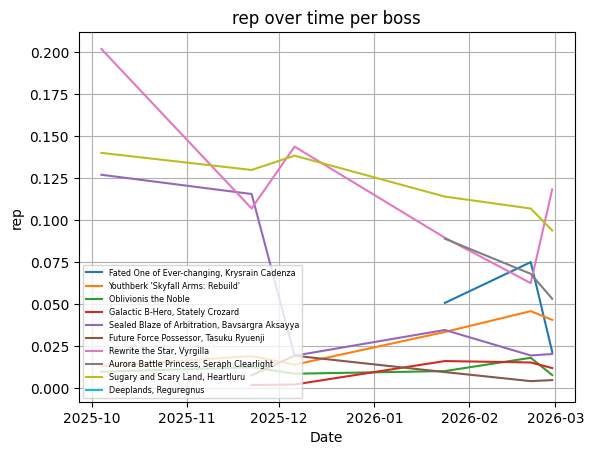

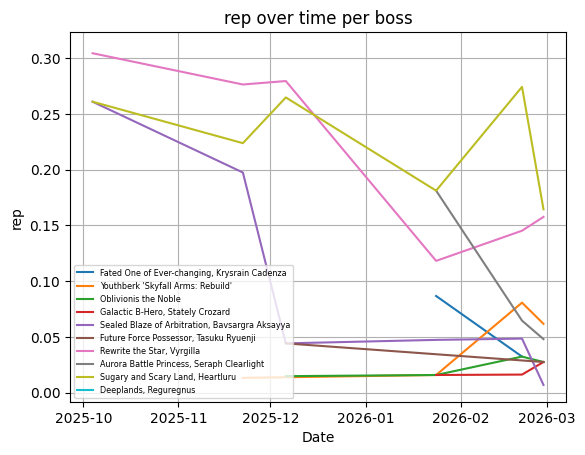

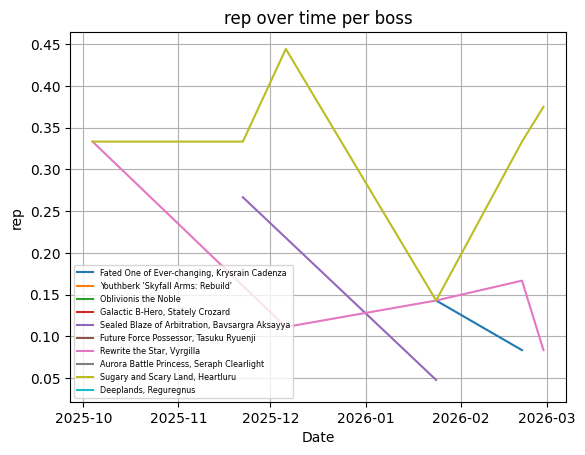

In [19]:
adfs = break_df_by_format(full_df, formats)
tdfs = break_df_by_format(top_df, formats)
cdfs = break_df_by_format(champ_df, formats)



for dfs in [adfs, tdfs, cdfs]:
    list = []
    for df in dfs:
        tmp = boss_representation_in_format(df)
        list.append(tmp)

    list = pd.concat(list)

    graph_over_format(list, 'boss', 'rep', big_10_names, formats)